In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import CUSTOMER_FEATURES, RANDOM_STATE

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load feature-engineered data

In [3]:
df = pd.read_csv(CUSTOMER_FEATURES)
df.shape

(5878, 12)

## Prepare Features and Target

We use recency, frequency, monetary, avg_order_value, and Country as predictors.
R_score/F_score/M_score/RFM_score/segment are derived FROM is_churned's own inputs
(recency threshold), so we exclude the score/segment columns to avoid leakage —
only raw RFM values go into the model.

In [12]:
features = ["frequency", "monetary", "avg_order_value", "Country"]
target = "is_churned"

X = df[features]
y = df[target]

X.head()

,frequency,monetary,avg_order_value,Country
0,12,77556.46,6463.038333,United Kingdom
1,8,4921.53,615.191250,Iceland
2,5,2019.40,403.880000,Finland
3,4,4428.69,1107.172500,Italy
4,1,334.40,334.400000,Norway


# Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Preprocessing pipeline

In [14]:
numeric_features = ["frequency", "monetary", "avg_order_value"]
categorical_features = ["Country"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

## Compare Multiple Algorithms with Cross-Validation

Each model is wrapped in the same preprocessing pipeline and evaluated using 5-fold
stratified cross-validation on F1-score (since churn is the class of real business
interest, and we care about both precision and recall).

In [15]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    roc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")

    results.append({
        "model": name,
        "f1_mean": f1_scores.mean(),
        "f1_std": f1_scores.std(),
        "roc_auc_mean": roc_scores.mean(),
        "roc_auc_std": roc_scores.std()
    })
    print(f"{name}: F1 = {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f}), ROC-AUC = {roc_scores.mean():.4f}")

results_df = pd.DataFrame(results).sort_values("f1_mean", ascending=False)
results_df

LogisticRegression: F1 = 0.7265 (+/- 0.0118), ROC-AUC = 0.7605
DecisionTree: F1 = 0.6249 (+/- 0.0141), ROC-AUC = 0.6132
RandomForest: F1 = 0.6329 (+/- 0.0123), ROC-AUC = 0.6883
XGBoost: F1 = 0.6932 (+/- 0.0114), ROC-AUC = 0.7285


,model,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,LogisticRegression,0.726485,0.011813,0.760482,0.016031
3,XGBoost,0.693161,0.011383,0.728517,0.009923
2,RandomForest,0.632887,0.012287,0.688334,0.011414
1,DecisionTree,0.624896,0.014051,0.613218,0.013006


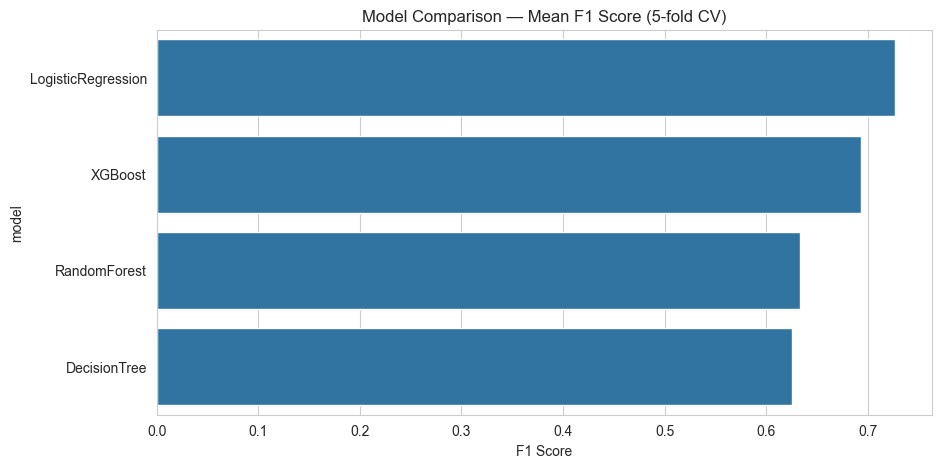

In [16]:
plt.figure()
sns.barplot(x="f1_mean", y="model", data=results_df)
plt.title("Model Comparison — Mean F1 Score (5-fold CV)")
plt.xlabel("F1 Score")
plt.show()

# Save Comparison table as an artifacts

In [17]:
os.makedirs("../artifacts", exist_ok=True)
results_df.to_csv("../artifacts/model_comparison.csv", index=False)
print("Saved model comparison to artifacts/model_comparison.csv")

Saved model comparison to artifacts/model_comparison.csv


## Hyperparameter Tuning (Best Model Only)

Based on the comparison above, we tune only the top-performing model rather than
tuning all of them — the others already showed clearly lower performance under CV.

In [18]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model: {best_model_name}")

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_

Best model: LogisticRegression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1 score: 0.7348


In [19]:
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.53      0.63       578
           1       0.65      0.86      0.74       598

    accuracy                           0.70      1176
   macro avg       0.72      0.69      0.69      1176
weighted avg       0.72      0.70      0.69      1176

Test F1 Score: 0.7431
Test ROC-AUC: 0.7787


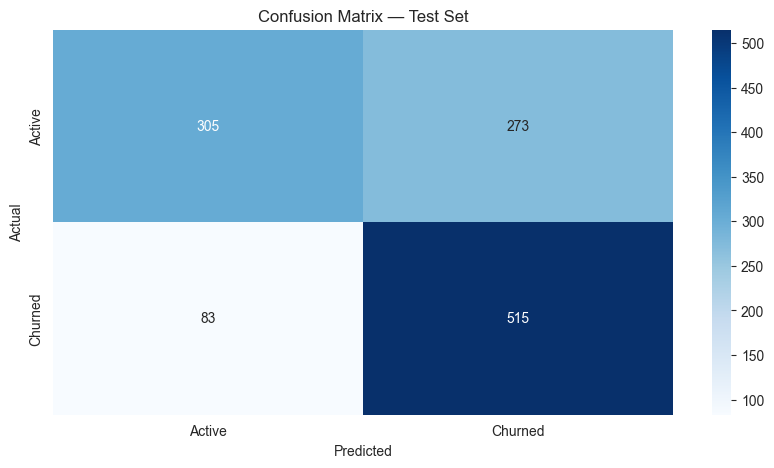

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"])
plt.title("Confusion Matrix — Test Set")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

<Figure size 1000x500 with 0 Axes>

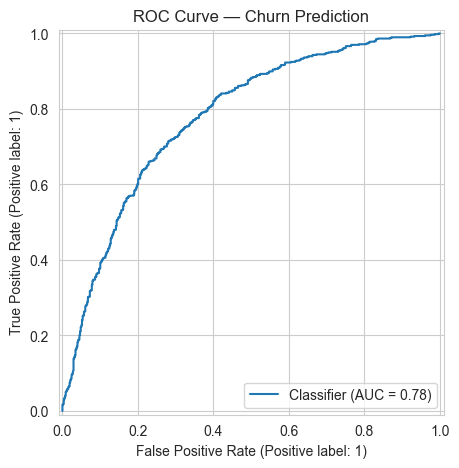

In [21]:
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve — Churn Prediction")
plt.show()

In [23]:
!pip install shap


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


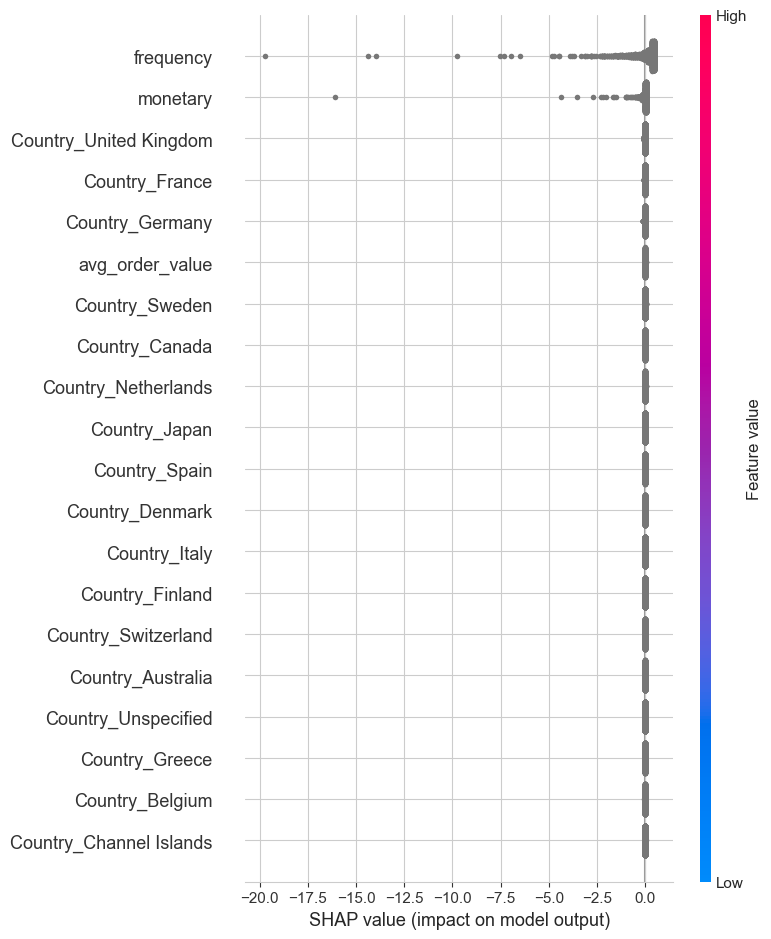

In [25]:
import shap

# Transform test data through the preprocessor to get feature names
X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = (numeric_features +
    list(best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)))

explainer = shap.LinearExplainer(best_pipeline.named_steps["classifier"], X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)

In [26]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/churn_model.pkl")
print("Model saved to models/churn_model.pkl")

Model saved to models/churn_model.pkl


## Modeling Summary

- Compared 4 algorithms via 5-fold stratified cross-validation: Logistic Regression,
  Decision Tree, Random Forest, XGBoost
- Best model: **Logistic Regression**, with CV F1 = **0.7265** (+/- 0.0118), ROC-AUC = **0.7605**
  — outperforming all three tree-based models, suggesting the relationship between
  frequency, monetary, avg_order_value, and churn is largely linear/monotonic
- After hyperparameter tuning (C=0.01, penalty='l2', solver='lbfgs'):
  Best CV F1 = **0.7348**
- Final test set performance: **F1 = 0.7431, ROC-AUC = 0.7787, Accuracy = 70%**
- Precision/Recall trade-off observed: the model catches churners well (Recall = 0.86
  for class 1) but at the cost of more false positives (Precision = 0.65) — meaning it
  flags more active customers as at-risk than it misses actual churners. This is a
  reasonable trade-off for a retention use case, where the cost of a missed churner
  (lost customer) is typically higher than the cost of a false alarm (an unnecessary
  retention offer to an active customer)
- SHAP analysis confirms frequency and monetary value as the strongest churn drivers,
  consistent with the statistical testing findings in Step 12
- Final model saved to `models/churn_model.pkl`, ready for deployment via FastAPI